In [36]:
!pip install shap --quiet

In [37]:
import pandas as pd
df = pd.read_csv('data/train.csv')

In [38]:
df.shape

(4701217, 23)

In [39]:
df.dtypes

id                        object
base_date                  int64
day_of_week               object
base_hour                  int64
lane_count                 int64
road_rating                int64
road_name                 object
multi_linked               int64
connect_code               int64
maximum_speed_limit      float64
vehicle_restricted       float64
weight_restricted        float64
height_restricted        float64
road_type                  int64
start_node_name           object
start_latitude           float64
start_longitude          float64
start_turn_restricted     object
end_node_name             object
end_latitude             float64
end_longitude            float64
end_turn_restricted       object
target                   float64
dtype: object

In [40]:
# !pip install plotly folium

In [41]:
import os 
import json
import numpy as np
from pandas.api.types import CategoricalDtype
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor #RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler # Normal distibution
import folium
import shap

shap.initjs()

In [42]:
df.head(10)

,id,base_date,day_of_week,base_hour,lane_count,road_rating,road_name,multi_linked,connect_code,maximum_speed_limit,...,road_type,start_node_name,start_latitude,start_longitude,start_turn_restricted,end_node_name,end_latitude,end_longitude,end_turn_restricted,target
0,TRAIN_0000000,20220623,목,17,1,106,지방도1112호선,0,0,60.0,...,3,제3교래교,33.427747,126.662612,없음,제3교래교,33.427749,126.662335,없음,52.0
1,TRAIN_0000001,20220728,목,21,2,103,일반국도11호선,0,0,60.0,...,0,광양사거리,33.500730,126.529107,있음,KAL사거리,33.504811,126.526240,없음,30.0
2,TRAIN_0000002,20211010,일,7,2,103,일반국도16호선,0,0,80.0,...,0,창고천교,33.279145,126.368598,없음,상창육교,33.280072,126.362147,없음,61.0
3,TRAIN_0000003,20220311,금,13,2,107,태평로,0,0,50.0,...,0,남양리조트,33.246081,126.567204,없음,서현주택,33.245565,126.566228,없음,20.0
4,TRAIN_0000004,20211005,화,8,2,103,일반국도12호선,0,0,80.0,...,0,애월샷시,33.462214,126.326551,없음,애월입구,33.462677,126.330152,없음,38.0
5,TRAIN_0000005,20210913,월,7,2,107,경찰로,0,0,60.0,...,0,시청입구2,33.249949,126.505664,없음,서호2차현대맨션203동,33.252183,126.506069,없음,28.0
6,TRAIN_0000006,20220106,목,0,2,107,-,0,0,60.0,...,0,가동,33.418412,126.268029,없음,나동,33.414175,126.269378,없음,39.0
7,TRAIN_0000007,20211213,월,16,2,107,외도천교,0,0,60.0,...,3,외도천교,33.482392,126.441622,없음,외도천교,33.482332,126.442266,없음,28.0
8,TRAIN_0000008,20211004,월,15,2,107,경찰로,0,0,60.0,...,0,신성교회,33.253074,126.506393,없음,서호2차현대맨션203동,33.252183,126.506069,없음,14.0
9,TRAIN_0000009,20211208,수,2,1,103,일반국도16호선,0,0,50.0,...,0,양수장,33.361717,126.766958,없음,제2가시교,33.364336,126.769409,없음,52.0


In [43]:
df.groupby('road_name')['target'].mean() # 도로 이름별 평균 속도

road_name
-         44.774556
경찰로       24.686785
고평교       36.126862
관광단지1로    39.292453
관광단지2로    34.469287
            ...    
첨단로       47.246703
태평로       25.030004
한천로       22.745260
호근로       32.086882
호서중앙로     32.510819
Name: target, Length: 61, dtype: float64

In [44]:
map_data = df.groupby(['start_latitude', 'start_longitude', 'end_latitude', 'end_longitude'])['target'].mean().reset_index().sort_values('target', ascending=False)
map_data

,start_latitude,start_longitude,end_latitude,end_longitude,target
296,33.298938,126.333934,33.298624,126.333607,81.150366
330,33.321270,126.350778,33.320921,126.350630,80.933483
335,33.322851,126.351447,33.321270,126.350778,80.933483
327,33.320921,126.350630,33.311538,126.345810,80.933296
493,33.419479,126.405897,33.421109,126.407259,78.074432
...,...,...,...,...,...
624,33.461055,126.444333,33.460157,126.446843,14.929801
867,33.519832,126.588049,33.521399,126.587288,14.533360
743,33.489940,126.490153,33.490078,126.486558,13.518895
651,33.468664,126.678235,33.437249,126.677154,11.729073


In [45]:

map = folium.Map(location=[33.308412, 126.488029], zoom_start=10)
folium.Marker([33.418412, 126.268029], popup='Start', icon=folium.Icon(color='blue')).add_to(map)
folium.Marker([33.414175, 126.269378], popup='End', icon=folium.Icon(color='blue')).add_to(map)
def to_line(x):
    if x['target'] > 80: target_color='green' # 
    elif x['target'] > 50: target_color='blue'
    elif x['target'] > 30: target_color='orange'
    else: target_color='red'
    folium.PolyLine(locations=[[x['start_latitude'], x['start_longitude']], [x['end_latitude'], x['end_longitude']]], tooltip='Polyline',color=target_color).add_to(map)
map_data.apply(to_line, axis=1)    
map

In [46]:
df.columns.tolist()

['id',
 'base_date',
 'day_of_week',
 'base_hour',
 'lane_count',
 'road_rating',
 'road_name',
 'multi_linked',
 'connect_code',
 'maximum_speed_limit',
 'vehicle_restricted',
 'weight_restricted',
 'height_restricted',
 'road_type',
 'start_node_name',
 'start_latitude',
 'start_longitude',
 'start_turn_restricted',
 'end_node_name',
 'end_latitude',
 'end_longitude',
 'end_turn_restricted',
 'target']

In [47]:
num_columns = df.select_dtypes(include=np.number).columns.tolist()
col_columns = df.select_dtypes(include=object).columns.tolist()

In [48]:
num_columns

['base_date',
 'base_hour',
 'lane_count',
 'road_rating',
 'multi_linked',
 'connect_code',
 'maximum_speed_limit',
 'vehicle_restricted',
 'weight_restricted',
 'height_restricted',
 'road_type',
 'start_latitude',
 'start_longitude',
 'end_latitude',
 'end_longitude',
 'target']

In [49]:
col_columns

['id',
 'day_of_week',
 'road_name',
 'start_node_name',
 'start_turn_restricted',
 'end_node_name',
 'end_turn_restricted']

In [50]:
df[['id', 'day_of_week', 'road_name', 'start_node_name', 'end_node_name']]

,id,day_of_week,road_name,start_node_name,end_node_name
0,TRAIN_0000000,목,지방도1112호선,제3교래교,제3교래교
1,TRAIN_0000001,목,일반국도11호선,광양사거리,KAL사거리
2,TRAIN_0000002,일,일반국도16호선,창고천교,상창육교
3,TRAIN_0000003,금,태평로,남양리조트,서현주택
4,TRAIN_0000004,화,일반국도12호선,애월샷시,애월입구
...,...,...,...,...,...
4701212,TRAIN_4701212,목,-,대림사거리,금덕해운
4701213,TRAIN_4701213,목,-,광삼교,광삼교
4701214,TRAIN_4701214,월,일반국도12호선,고성교차로,성산교차로
4701215,TRAIN_4701215,수,일반국도95호선,제6광령교,관광대학입구


In [51]:
df['base_date'] = pd.to_datetime(df['base_date'], format='%Y%m%d') # base date to time format
df['year'] = df['base_date'].dt.year # year format
df['month'] = df['base_date'].dt.month # month format
df['dayofweek'] = df['base_date'].dt.dayofweek # day of week format
df = df.drop(['id', 'base_date', 'day_of_week', 'road_name', 'start_node_name', 'end_node_name'], axis=1) 
df
   


,base_hour,lane_count,road_rating,multi_linked,connect_code,maximum_speed_limit,vehicle_restricted,weight_restricted,height_restricted,road_type,start_latitude,start_longitude,start_turn_restricted,end_latitude,end_longitude,end_turn_restricted,target,year,month,dayofweek
0,17,1,106,0,0,60.0,0.0,32400.0,0.0,3,33.427747,126.662612,없음,33.427749,126.662335,없음,52.0,2022,6,3
1,21,2,103,0,0,60.0,0.0,0.0,0.0,0,33.500730,126.529107,있음,33.504811,126.526240,없음,30.0,2022,7,3
2,7,2,103,0,0,80.0,0.0,0.0,0.0,0,33.279145,126.368598,없음,33.280072,126.362147,없음,61.0,2021,10,6
3,13,2,107,0,0,50.0,0.0,0.0,0.0,0,33.246081,126.567204,없음,33.245565,126.566228,없음,20.0,2022,3,4
4,8,2,103,0,0,80.0,0.0,0.0,0.0,0,33.462214,126.326551,없음,33.462677,126.330152,없음,38.0,2021,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4701212,16,1,107,0,0,50.0,0.0,0.0,0.0,0,33.422145,126.278125,없음,33.420955,126.273750,없음,20.0,2021,11,3
4701213,2,2,107,0,0,80.0,0.0,43200.0,0.0,3,33.472505,126.424368,없음,33.472525,126.424890,없음,65.0,2022,3,3
4701214,22,2,103,0,0,60.0,0.0,0.0,0.0,0,33.447183,126.912579,없음,33.444121,126.912948,없음,30.0,2022,6,0
4701215,2,2,103,0,0,80.0,0.0,0.0,0.0,0,33.443596,126.431817,없음,33.444996,126.433332,없음,73.0,2021,10,2


In [52]:
# Boolean으로 사용할 수 있는 변수 추출하기
# df[df['start_turn_restricted'] == "없음"] = 0
# df.loc['start_turn_restricted'=='없음', start_turn_restricted] = 0
# df[df['start_turn_restricted'] == "있음"] = 1
df['start_turn_restricted'] = df['start_turn_restricted'].astype('category').cat.codes # start_turn_restricted to 0 and 1. Change to number
df['end_turn_restricted'] = df['end_turn_restricted'].astype('category').cat.codes # end_turn_restricted to 0 and 1
df

,base_hour,lane_count,road_rating,multi_linked,connect_code,maximum_speed_limit,vehicle_restricted,weight_restricted,height_restricted,road_type,start_latitude,start_longitude,start_turn_restricted,end_latitude,end_longitude,end_turn_restricted,target,year,month,dayofweek
0,17,1,106,0,0,60.0,0.0,32400.0,0.0,3,33.427747,126.662612,0,33.427749,126.662335,0,52.0,2022,6,3
1,21,2,103,0,0,60.0,0.0,0.0,0.0,0,33.500730,126.529107,1,33.504811,126.526240,0,30.0,2022,7,3
2,7,2,103,0,0,80.0,0.0,0.0,0.0,0,33.279145,126.368598,0,33.280072,126.362147,0,61.0,2021,10,6
3,13,2,107,0,0,50.0,0.0,0.0,0.0,0,33.246081,126.567204,0,33.245565,126.566228,0,20.0,2022,3,4
4,8,2,103,0,0,80.0,0.0,0.0,0.0,0,33.462214,126.326551,0,33.462677,126.330152,0,38.0,2021,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4701212,16,1,107,0,0,50.0,0.0,0.0,0.0,0,33.422145,126.278125,0,33.420955,126.273750,0,20.0,2021,11,3
4701213,2,2,107,0,0,80.0,0.0,43200.0,0.0,3,33.472505,126.424368,0,33.472525,126.424890,0,65.0,2022,3,3
4701214,22,2,103,0,0,60.0,0.0,0.0,0.0,0,33.447183,126.912579,0,33.444121,126.912948,0,30.0,2022,6,0
4701215,2,2,103,0,0,80.0,0.0,0.0,0.0,0,33.443596,126.431817,0,33.444996,126.433332,0,73.0,2021,10,2


In [53]:
df.dtypes

base_hour                  int64
lane_count                 int64
road_rating                int64
multi_linked               int64
connect_code               int64
maximum_speed_limit      float64
vehicle_restricted       float64
weight_restricted        float64
height_restricted        float64
road_type                  int64
start_latitude           float64
start_longitude          float64
start_turn_restricted       int8
end_latitude             float64
end_longitude            float64
end_turn_restricted         int8
target                   float64
year                       int64
month                      int64
dayofweek                  int64
dtype: object

In [54]:
df.isnull().sum()

base_hour                0
lane_count               0
road_rating              0
multi_linked             0
connect_code             0
maximum_speed_limit      0
vehicle_restricted       0
weight_restricted        0
height_restricted        0
road_type                0
start_latitude           0
start_longitude          0
start_turn_restricted    0
end_latitude             0
end_longitude            0
end_turn_restricted      0
target                   0
year                     0
month                    0
dayofweek                0
dtype: int64

In [55]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
base_hour,4701217.0,11.93,6.72,0.00,6.00,12.00,18.00,23.00
lane_count,4701217.0,1.84,0.69,1.00,1.00,2.00,2.00,3.00
road_rating,4701217.0,104.96,1.84,103.00,103.00,106.00,107.00,107.00
multi_linked,4701217.0,0.00,0.02,0.00,0.00,0.00,0.00,1.00
connect_code,4701217.0,0.27,5.23,0.00,0.00,0.00,0.00,103.00
maximum_speed_limit,4701217.0,61.25,12.13,30.00,50.00,60.00,70.00,80.00
vehicle_restricted,4701217.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
weight_restricted,4701217.0,5618.74,13953.43,0.00,0.00,0.00,0.00,50000.00
height_restricted,4701217.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
road_type,4701217.0,0.62,1.21,0.00,0.00,0.00,0.00,3.00


In [56]:
len(df.columns.tolist())

20

In [57]:
df.shape

(4701217, 20)

In [58]:
y = df.pop('target')
X = df

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # X, y split.

sc = StandardScaler() # StandardScaler
sc.fit(X_train) # fit the scaler to the training data

X_train_std = sc.transform(X_train) # transform the training data
X_test_std  = sc.transform(X_test) # transform the test data

rf_clf = RandomForestRegressor(n_estimators=100, max_depth=5, n_jobs=-1, verbose=1, random_state=0)

rf_clf.fit(X_train_std, y_train)

predicted_train = rf_clf.predict(X_train_std)
predicted_test = rf_clf.predict(X_test_std)

print(f"{mean_absolute_percentage_error(predicted_train, y_train)}")
print(f"{mean_absolute_percentage_error(predicted_test, y_test)}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.0min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s


0.20098176370201384
0.20100248133479878


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.5s finished


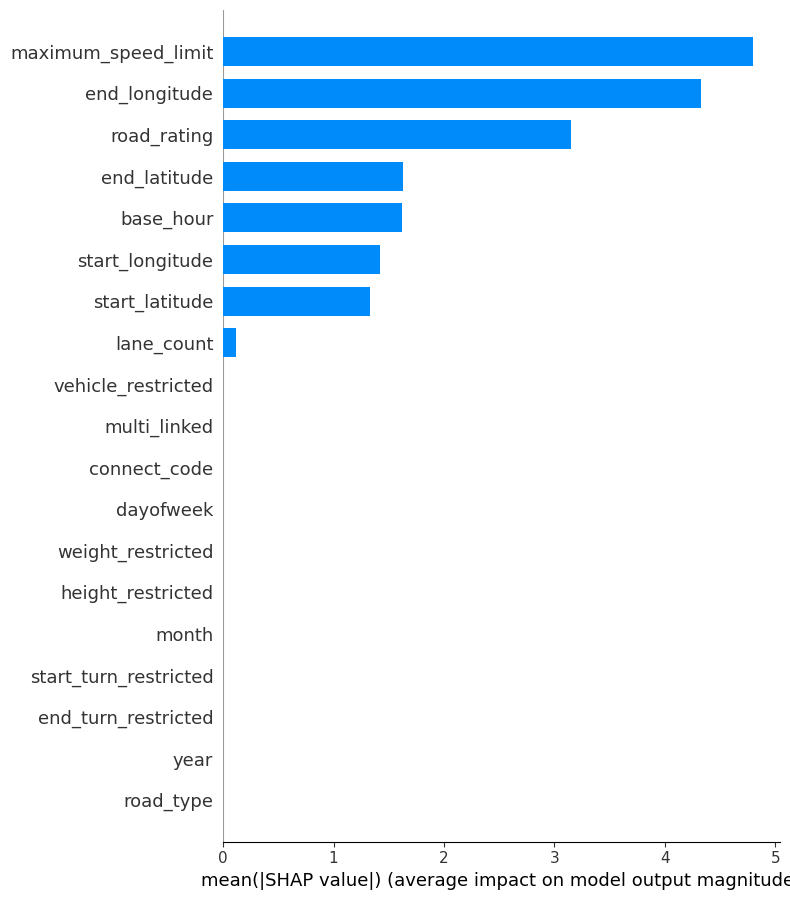

In [60]:
explainer = shap.Explainer(rf_clf)
shap_values = explainer(X_test_std)
shap.summary_plot(shap_values, X_test, plot_type='bar')

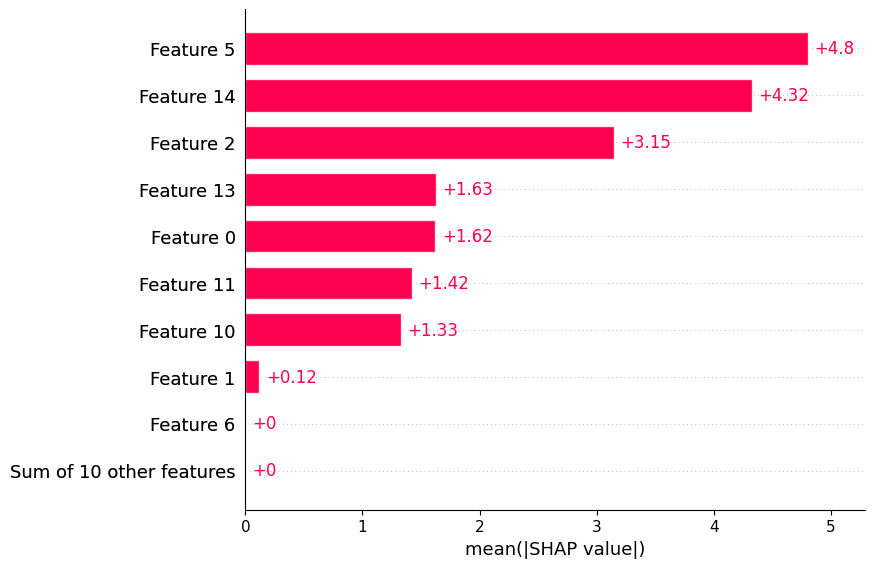

In [61]:
shap.plots.bar(shap_values)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X[['maximum_speed_limit','end_latitude','start_latitude','road_rating','start_longitude','base_hour','end_longitude','lane_count']], y, test_size=0.2, random_state=0)

sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std  = sc.transform(X_test)

rf_clf = RandomForestRegressor(n_estimators=100, max_depth=5, n_jobs=-1, verbose=1, random_state=0)

rf_clf.fit(X_train_std, y_train)

predicted_train = rf_clf.predict(X_train_std)
predicted_test = rf_clf.predict(X_test_std)

print(f"{mean_absolute_percentage_error(predicted_train, y_train)}")
print(f"{mean_absolute_percentage_error(predicted_test, y_test)}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s


0.20098176370201384
0.20100248133479878


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.4s finished


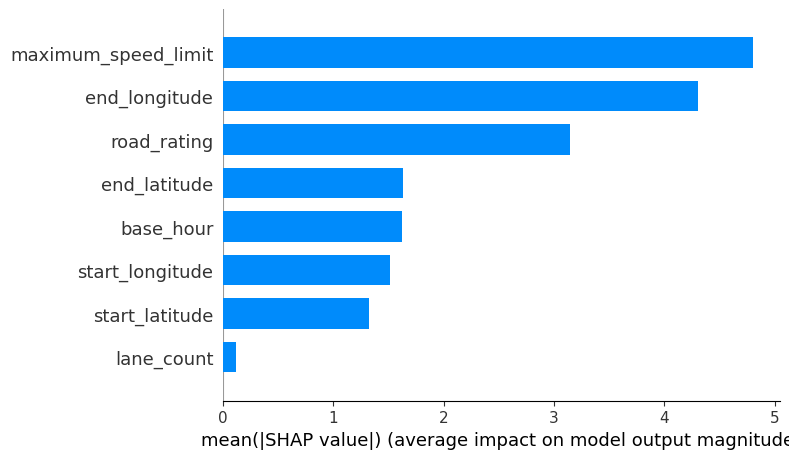

In [63]:
explainer = shap.Explainer(rf_clf)
shap_values = explainer(X_test_std)
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [64]:
X_test

,maximum_speed_limit,end_latitude,start_latitude,road_rating,start_longitude,base_hour,end_longitude,lane_count
2496174,80.0,33.554302,33.555316,103,126.736681,18,126.738379,2
2103537,70.0,33.254628,33.254233,103,126.565958,2,126.567678,3
3275898,60.0,33.402546,33.401188,107,126.874796,12,126.864244,1
2004567,50.0,33.283593,33.284189,107,126.723306,14,126.720591,1
4360316,60.0,33.444121,33.447183,103,126.912579,20,126.912948,2
...,...,...,...,...,...,...,...,...
3728595,70.0,33.490078,33.488395,103,126.483507,5,126.486558,3
3863964,50.0,33.344628,33.345240,103,126.850113,13,126.849279,2
3943981,70.0,33.529889,33.527867,103,126.613582,7,126.616461,2
563142,30.0,33.251812,33.251003,107,126.412163,10,126.412607,1


In [66]:
!pip install xgboost
import xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
    --------------------------------------- 2.6/124.9 MB 15.1 MB/s eta 0:00:09
   - -------------------------------------- 5.8/124.9 MB 16.0 MB/s eta 0:00:08
   -- ------------------------------------- 8.4/124.9 MB 14.9 MB/s eta 0:00:08
   --- ------------------------------------ 11.8/124.9 MB 15.1 MB/s eta 0:00:08
   ---- ----------------------------------- 14.9/124.9 MB 14.9 MB/s eta 0:00:08
   ----- ---------------------------------- 17.8/124.9 MB 15.0 MB/s eta 0:00:08
   ------ --------------------------------- 21.0/124.9 MB 15.1 MB/s eta 0:00:07
   ------- -------------------------------- 24.4/124.9 MB 15.3 MB/s eta 0:00:07
   -------- ------------------------------- 26.7/124.9 MB 15.0 MB/s eta 0:00:07
   --------- ------------------------------ 29.9/124.9 MB 14.8 MB/s eta 0:00:07
   ---------- ----------------------------- 33.0/124.9 MB 14.9 MB/s eta 0:00:07
   ----------- ---------------------------- 36.2/124

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

'''sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std  = sc.transform(X_test)
'''
xgb_model = xgboost.XGBRegressor(n_estimators=100, max_depth=5)
xgb_model.fit(X_train, y_train)

xgb_predicted_train = xgb_model.predict(X_train)
xgb_predicted_test = xgb_model.predict(X_test)

print(f"{mean_absolute_percentage_error(xgb_predicted_train, y_train)}")
print(f"{mean_absolute_percentage_error(xgb_predicted_test, y_test)}")

0.11501289922571893
0.11500327762331414


In [68]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)